# Researcher as an agent

In the previous notebook, we build an a workflow with clear explicit steps.   

In this notebook, we will convert the previous flows as tool and create a react agent 

## Imports

In [1]:
import sys 
sys.path.insert(0,"../code")

In [11]:
import utils_display
import prompts
import utils
from utils_import import *
from langchain_core.messages import HumanMessage, SystemMessage


## Tools



We will define an agent with three tools: web search, think, and summarize findings.

Note the web search tool, just wraps the exiting `web_search` function we defined earlier.

In [3]:
from IPython.display import Code
Code(filename='../code/tools.py', language='python')


import utils
import constants
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI


@tool
def web_search_tool(query: str, max_results: int = 3) -> str:
    """Search the web for information about a specific query.
    
    Args:
        query: The search query (be specific for better results)
        max_results: Number of results to return (1-5)
        
    Returns:
        Formatted search results with sources
    """
    print(f"🔍 Searching: {query}")

    results = utils.web_search(query, max_results=max_results)

    return results


@tool
def think_tool(reasoning: str) -> str:
    """Document your thinking process.

    Use this to analyze findings, plan next steps, and show your reasoning.

    Args:
        reasoning: Your detailed thought process
    """
    print(f"💭 Thinking: {reasoning[:100]}...")
    return f"Reasoning recorded: {reasoning}"


@tool
def summarize_findings_tool(findings: str) -> str:
    """Summarize and organize research findings.
    
    Args:
        findings: The raw findings to summarize
    """
    print(f"📝 Summarizing {len(findings)} chars of findings")
    
    model = ChatOpenAI(
        model="gpt-4o",
        base_url=constants.OPENAI_BASE_URL,
        max_tokens=16000,
    )

    system_prompt = f"""You are a research summarization assistant. Today is {utils.get_today_str()}.

Create a comprehensive research summary with:
1. Key information organized clearly
2. Inline citations [1], [2], etc.
3. Sources list at the end

Format:
**Summary**
[Findings with citations]

**Sources**
[1] Source 1
[2] Source 2
"""
    
    response = model.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Summarize:\n\n{findings}")
    ])
    
    return response.content

In [4]:
import tools

In [ ]:
# Bundle tools
tools = [tools.web_search_tool, tools.think_tool, tools.summarize_findings_tool]


✅ 3 tools defined


## Agent System Prompt

In [6]:
utils_display.show_prompt(prompts.agent_system_prompt, "Agent System Prompt")

╭────────────────────────────────────────────── Agent System Prompt ──────────────────────────────────────────────╮
│                                                                                                                 │
│  You are an expert research assistant with access to web search capabilities.                                   │
│                                                                                                                 │
│  Today's date is {date}.                                                                                        │
│                                                                                                                 │
│  # Available Tools                                                                                              │
│                                                                                                                 │
│  You have access to these tools:                                                                                │
│  1. **web_search(query, max_results)**: Search the internet for information                                     │
│  2. **think(reasoning)**: Document your reasoning and planning (USE THIS LIBERALLY!)                            │
│  3. **summarize_findings(findings)**: Organize collected information into a final report                        │
│                                                                                                                 │
│  # Research Process                                                                                             │
│                                                                                                                 │
│  Follow this iterative process:                                                                                 │
│                                                                                                                 │
│  1. **THINK FIRST**: Start by using think() to:                                                                 │
│     - Break down the research question into key aspects                                                         │
│     - Identify what information you need to gather                                                              │
│     - Plan your search strategy                                                                                 │
│                                                                                                                 │
│  2. **SEARCH STRATEGICALLY**: Use web_search() to:                                                              │
│     - Find specific information on each aspect                                                                  │
│     - Gather diverse perspectives and sources                                                                   │
│     - Fill knowledge gaps                                                                                       │
│     - Be specific with queries for better results                                                               │
│                                                                                                                 │
│  3. **REFLECT REGULARLY**: After each search, use think() to:                                                   │
│     - Analyze what you learned from the search                                                                  │
│     - Identify what information is still missing                                                                │
│     - Plan your next search or decide if you're done                                                            │
│                                                                                                                 │
│  4. **ITERATE**: Continue searching and thinking until you have comprehensive information                       │
│     - Make 2-4 searches typically                     

In [7]:
system_message = prompts.agent_system_prompt.format(date=utils.get_today_str())

## Build Agent

Instead of manually creating the graph, lets just build the agent with tools using `create_react_agent`

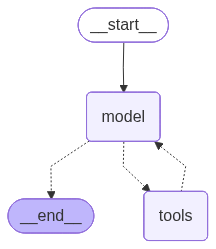

In [8]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

# Create LLM
llm = ChatOpenAI(
    model="gpt-4o",
    base_url=OPENAI_BASE_URL,
    temperature=0.7
)

agent = create_agent(
    llm,                          # The LLM to use
    tools,                        # List of tools
    system_prompt=system_message # System prompt
)

agent

The agent node calls the language model with the messages list (after applying the system prompt). 

If the resulting AIMessage contains tool_calls, the graph will then call the tools. 

The tools node executes the tools and adds the responses to the messages list as ToolMessage objects. 

The agent node then calls the language model again. 

The process repeats until no more tool_calls are present in the response. 

The agent then returns the full list of messages.

[LangChain Docs](https://reference.langchain.com/python/langchain/agents/#langchain.agents.create_agent(debug))

## Invoke Graph

In [9]:
# Run a research query


topic = """I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance. 
My goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their ambiance,
including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified preferences
regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities, so these
should be considered flexible unless they are relevant to ambiance. Please prioritize information from official
coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible local
publications. The research should be current as of October 2025."""



In [12]:
with tracer.start_as_current_span("research_agent_tool"):
    initial_state = {
        "messages": [HumanMessage(content=topic)]
    }
    
    result = agent.invoke(initial_state)

💭 Thinking: To effectively research the best coffee shops in Seattle with a focus on ambiance, I need to break d...
🔍 Searching: best coffee shops in Seattle for ambiance 2025
🔍 Searching: best coffee shops in Seattle for ambiance 2025
🔍 Searching: Seattle coffee shop ambiance reviews 2025
🔍 Searching: Seattle coffee shop ambiance reviews 2025
🔍 Searching: Seattle coffee shop interior design 2025
🔍 Searching: Seattle coffee shop interior design 2025
💭 Thinking: The initial search results have provided a range of insights into Seattle's coffee shops with a focu...
🔍 Searching: Storyville Coffee Company Seattle ambiance
🔍 Searching: Storyville Coffee Company Seattle ambiance
🔍 Searching: Moore Coffee Shop Seattle ambiance
🔍 Searching: Moore Coffee Shop Seattle ambiance
🔍 Searching: Zeitgeist Coffee Seattle ambiance
🔍 Searching: Zeitgeist Coffee Seattle ambiance
💭 Thinking: The focused searches have yielded detailed descriptions of the ambiance and interior design features...
📝 Summarizin

In [13]:
result

{'messages': [HumanMessage(content='I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance. \nMy goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their ambiance,\nincluding factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified preferences\nregarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities, so these\nshould be considered flexible unless they are relevant to ambiance. Please prioritize information from official\ncoffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible local\npublications. The research should be current as of October 2025.', additional_kwargs={}, response_metadata={}, id='92d977c6-275d-48fa-b281-e94d2130a6bb'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 

In [14]:
utils_display.format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance.         │
│ My goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their     │
│ ambiance,                                                                                                       │
│ including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified          │
│ preferences                                                                                                     │
│ regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities,  │
│ so these                                                                                                        │
│ should be considered flexible unless they are relevant to ambiance. Please prioritize information from official │
│ coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible   │
│ local                                                                                                           │
│ publications. The research should be current as of October 2025.                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reasoning": "To effectively research the best coffee shops in Seattle with a focus on ambiance, I need to    │
│ break down the key aspects of ambiance that are important for evaluation. These include:\n\n1. **Interior       │
│ Design**: Aesthetic appeal, creativity, and uniqueness of the decor.\n2. **Atmosphere**: The overall mood of    │
│ the place, including noise levels and lighting.\n3. **Comfort**: Furniture quality, seating arrangement, and    │
│ space layout.\n4. **Overall Vibe**: The combined effect of all factors that create a unique                     │
│ experience.\n\nNext, I will plan my search strategy. I should:\n\n1. Look for lists or articles from reputable  │
│ sources specifically about the best coffee shops in Seattle focusing on ambiance.\n2. Check coffee shop         │
│ websites for descriptions and photos that highlight their ambiance.\n3. Use review platforms like Yelp, Google  │
│ Reviews, or TripAdvisor to gather recent customer feedback focused on ambiance.\n4. Search for any local        │
│ Seattle publications or blogs that might have recent reviews or articles about coffee shop ambiance.\n\nGiven   │
│ the need for current information up to October 2025, I'll ensure that the sources are recent or updated         │
│ accordingly. I will start by performing a web search to cover these areas and gather initial insights."         │
│ }                                                                                                               │
│    ID: call_45xbaf46My95CspGlA9zzQKY                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reasoning recorded: To effectively research the best coffee shops in Seattle with a focus on ambiance, I need   │
│ to break down the key aspects of ambiance that are important for evaluation. These include:                     │
│                                                                                                                 │
│ 1. **Interior Design**: Aesthetic appeal, creativity, and uniqueness of the decor.                              │
│ 2. **Atmosphere**: The overall mood of the place, including noise levels and lighting.                          │
│ 3. **Comfort**: Furniture quality, seating arrangement, and space layout.                                       │
│ 4. **Overall Vibe**: The combined effect of all factors that create a unique experience.                        │
│                                                                                                                 │
│ Next, I will plan my search strategy. I should:                                                                 │
│                                                                                                                 │
│ 1. Look for lists or articles from reputable sources specifically about the best coffee shops in Seattle        │
│ focusing on ambiance.                                                                                           │
│ 2. Check coffee shop websites for descriptions and photos that highlight their ambiance.                        │
│ 3. Use review platforms like Yelp, Google Reviews, or TripAdvisor to gather recent customer feedback focused on │
│ ambiance.                                                                                                       │
│ 4. Search for any local Seattle publications or blogs that might have recent reviews or articles about coffee   │
│ shop ambiance.                                                                                                  │
│                                                                                                                 │
│ Given the need for current information up to October 2025, I'll ensure that the sources are recent or updated   │
│ accordingly. I will start by performing a web search to cover these areas and gather initial insights.          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: web_search_tool                                                                                   │
│    Args: {                                                                                                      │
│   "query": "best coffee shops in Seattle for ambiance 2025",                                                    │
│   "max_results": 3                                                                                              │
│ }                                                                                                               │
│    ID: call_rGN6F6VfOjpdUIfqedPw0CWr                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: web_search_tool                                                                                   │
│    Args: {                                                                                                      │
│   "query": "Seattle coffee shop ambiance reviews 2025",                                                         │
│   "max_results": 3                                                                                              │
│ }                                                                                                               │
│    ID: call_zQD4q8Fw61ppNH6RVBPwDCFY                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: web_search_tool                                                                                   │
│    Args: {                                                                                                      │
│   "query": "Seattle coffee shop interior design 2025",                                                          │
│   "max_results": 3                                                                                              │
│ }                                                                                                               │
│    ID: call_7U1zJb449ZYOxbpmLCE6XjRl                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results for: 'best coffee shops in Seattle for ambiance 2025'                                            │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: THE 10 BEST Cafés in Seattle (Updated 2025) - Tripadvisor ---                                     │
│ URL: https://www.tripadvisor.com/Restaurants-g60878-c8-Seattle_Washington.html                                  │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ A brief overview of top-rated bakeries in the area includes Baker Nouveau (4.8 stars from 1,270 reviews),       │
│ Storyville Coffee Pike Place (4.7 stars from 386 reviews), and Le Panier (4.6 stars) indicating a strong        │
│ preference for these establishments among customers.                                                            │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ 1. Bakery Nouveau - 4.8 (1,270 reviews)                                                                         │
│ 2. Storyville Coffee Pike Place - 4.7 (386 reviews)                                                             │
│ 3. Le Panier - 4.6                                                                                              │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│ --- SOURCE 2: 27 Best Coffee Shops in Seattle, WA For a Caffeine Fix ---                                        │
│ URL: https://www.emeraldpalate.com/best-coffee-shops-in-seattle/                                                │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ The webpage from The Emerald Palate presents a guide to the 27 best coffee shops in Seattle, highlighting their │
│ unique features and offerings. Seattle is celebrated as a premier coffee city, which makes selecting the best   │
│ spots both straightforward and challenging due to the abundance of quality establishments. Key highlights       │
│ include Ghost Note Coffee, known for its cocktail-inspired non-alcoholic coffee drinks; Onda Origins, praised   │
│ for its ethical sourcing; and Seattle Coffee Works, a modern hub for single-origin coffee. Each shop is         │
│ detailed with information on location, ambiance, specialties, and unique selling points, catering to a variety  │
│ of preferences—from cozy settings to artisanal brews. Other notable mentions include Boon Boona Coffee,         │
│ focusing on African blends, and Caffe Fiore, offering Caffe Vita coffee, among others. The guide encourages     │
│ exploration and appreciation of Seattle's diverse coffee culture.                                               │
│ </summary>                                             

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reasoning": "The focused searches have yielded detailed descriptions of the ambiance and interior design     │
│ features for Storyville Coffee Company, Moore Coffee Shop, and Zeitgeist Coffee, which are among the top-rated  │
│ coffee shops in Seattle for ambiance. Here's a summary of the findings:\n\n1. **Storyville Coffee Company**:\n  │
│ - Located in Pike Place Market, it's known for a cozy atmosphere with wood and leather furnishings, Edison      │
│ bulbs, and a fireplace, creating a lounge-like feel.\n   - The ambiance is complemented by friendly service and │
│ unique offerings, such as a free souvenir mug for first-time visitors.\n\n2. **Moore Coffee Shop**:\n   -       │
│ Features a vibrant and cozy setting with Latin-inspired decor, including Frida Kahlo artwork and colorful       │
│ furniture.\n   - The ambiance is described as a perfect blend of warmth and style, reflecting its Latina-owned  │
│ status.\n\n3. **Zeitgeist Coffee**:\n   - Situated in Pioneer Square, it combines ambiance, art, and            │
│ high-quality coffee, fostering a community-centered environment.\n   - The coffeehouse serves as a gallery for  │
│ local artists, with monthly exhibitions and receptions, enhancing its cultural vibe.\n\nThese findings align    │
│ well with the goal of evaluating coffee shops based on ambiance. I now have comprehensive information on the    │
│ ambiance of these prominent Seattle coffee shops, ready for a final summary."                                   │
│ }                                                                                                               │
│    ID: call_epBZIewxkfEW1XA9flPwbJYT                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reasoning recorded: The focused searches have yielded detailed descriptions of the ambiance and interior design │
│ features for Storyville Coffee Company, Moore Coffee Shop, and Zeitgeist Coffee, which are among the top-rated  │
│ coffee shops in Seattle for ambiance. Here's a summary of the findings:                                         │
│                                                                                                                 │
│ 1. **Storyville Coffee Company**:                                                                               │
│    - Located in Pike Place Market, it's known for a cozy atmosphere with wood and leather furnishings, Edison   │
│ bulbs, and a fireplace, creating a lounge-like feel.                                                            │
│    - The ambiance is complemented by friendly service and unique offerings, such as a free souvenir mug for     │
│ first-time visitors.                                                                                            │
│                                                                                                                 │
│ 2. **Moore Coffee Shop**:                                                                                       │
│    - Features a vibrant and cozy setting with Latin-inspired decor, including Frida Kahlo artwork and colorful  │
│ furniture.                                                                                                      │
│    - The ambiance is described as a perfect blend of warmth and style, reflecting its Latina-owned status.      │
│                                                                                                                 │
│ 3. **Zeitgeist Coffee**:                                                                                        │
│    - Situated in Pioneer Square, it combines ambiance, art, and high-quality coffee, fostering a                │
│ community-centered environment.                                                                                 │
│    - The coffeehouse serves as a gallery for local artists, with monthly exhibitions and receptions, enhancing  │
│ its cultural vibe.                                                                                              │
│                                                                                                                 │
│ These findings align well with the goal of evaluating coffee shops based on ambiance. I now have comprehensive  │
│ information on the ambiance of these prominent Seattle coffee shops, ready for a final summary.                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: summarize_findings_tool                                                                           │
│    Args: {                                                                                                      │
│   "findings": "The research on the best coffee shops in Seattle, with a focus on ambiance as of 2025,           │
│ highlights three standout establishments:\n\n1. **Storyville Coffee Company**:\n   - **Location**: Pike Place   │
│ Market, Seattle, WA.\n   - **Ambiance**: Known for its cozy, lounge-like atmosphere, featuring wood and leather │
│ furnishings, Edison bulbs, and a fireplace. This setup creates a warm and inviting environment akin to a        │
│ premium lounge.\n   - **Unique Features**: The coffee shop offers a unique customer experience with friendly    │
│ service and a complimentary souvenir mug for first-time visitors.\n\n2. **Moore Coffee Shop**:\n   -            │
│ **Location**: Downtown Seattle.\n   - **Ambiance**: Offers a vibrant and cozy setting with Latin-inspired       │
│ decor, highlighted by Frida Kahlo artwork and colorful furniture. The ambiance blends warmth and style,         │
│ creating a unique and inviting space.\n   - **Ownership**: The shop is Latina-owned, adding a personal and      │
│ cultural touch to its ambiance.\n\n3. **Zeitgeist Coffee**:\n   - **Location**: Pioneer Square, Seattle, WA.\n  │
│ - **Ambiance**: Zeitgeist combines a warm, community-centered atmosphere with an appreciation for local art. It │
│ functions as a gallery with monthly art exhibitions, enhancing its cultural and artistic vibe.\n   -            │
│ **Community Engagement**: The coffeehouse serves as a meeting place for the community, emphasizing the exchange │
│ of ideas and artistic expression.\n\nThese coffee shops are celebrated not only for their high-quality coffee   │
│ but also for their distinctive and inviting ambiances, making them top choices for both locals and visitors     │
│ seeking a unique coffee experience in Seattle."                                                                 │
│ }                                                                                                               │
│    ID: call_3hT9lr2nXHAtSIYMlZrlGdVq                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ **Summary**                                                                                                     │
│                                                                                                                 │
│ The research on Seattle's coffee shops in 2025 highlights three establishments with standout ambiances:         │
│                                                                                                                 │
│ 1. **Storyville Coffee Company** at Pike Place Market offers a cozy, lounge-like atmosphere characterized by    │
│ wood and leather furnishings, Edison bulbs, and a fireplace, providing a premium lounge experience. First-time  │
│ visitors receive a complimentary souvenir mug, enhancing the welcoming ambiance [1].                            │
│                                                                                                                 │
│ 2. **Moore Coffee Shop** in downtown Seattle features a vibrant and cozy Latin-inspired decor with Frida Kahlo  │
│ artwork and colorful furniture. As a Latina-owned establishment, it offers a personal and culturally rich       │
│ atmosphere [1].                                                                                                 │
│                                                                                                                 │
│ 3. **Zeitgeist Coffee** in Pioneer Square combines a community-centered atmosphere with local art appreciation, │
│ functioning as a gallery with monthly exhibitions. It serves as a hub for community engagement and artistic     │
│ expression [1].                                                                                                 │
│                                                                                                                 │
│ These coffee shops are renowned for their high-quality coffee and inviting ambiances, making them preferred     │
│ destinations for both locals and visitors seeking unique coffee experiences [1].                                │
│                                                                                                                 │
│ **Sources**                                                                                                     │
│ [1] Research on the best coffee shops in Seattle, 2025.                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Based on the research focusing on ambiance, here are three standout coffee shops in Seattle as of 2025:         │
│                                                                                                                 │
│ 1. **Storyville Coffee Company**:                                                                               │
│    - **Location**: Pike Place Market, Seattle, WA.                                                              │
│    - **Ambiance**: The shop offers a cozy, lounge-like atmosphere with wood and leather furnishings, Edison     │
│ bulbs, and a fireplace. This creates a warm, inviting environment akin to a premium lounge.                     │
│    - **Unique Features**: It provides a unique customer experience, including friendly service and a            │
│ complimentary souvenir mug for first-time visitors.                                                             │
│                                                                                                                 │
│ 2. **Moore Coffee Shop**:                                                                                       │
│    - **Location**: Downtown Seattle.                                                                            │
│    - **Ambiance**: Known for a vibrant and cozy setting with Latin-inspired decor, featuring Frida Kahlo        │
│ artwork and colorful furniture. This ambiance blends warmth and style, reflecting its Latina-owned status,      │
│ adding a personal cultural touch.                                                                               │
│                                                                                                                 │
│ 3. **Zeitgeist Coffee**:                                                                                        │
│    - **Location**: Pioneer Square, Seattle, WA.                                                                 │
│    - **Ambiance**: Zeitgeist combines a warm, community-centered atmosphere with an appreciation for local art. │
│ It functions as a gallery for local artists with monthly art exhibitions, enhancing its cultural and artistic   │
│ vibe.                                                                                                           │
│    - **Community Engagement**: The coffeehouse serves as a meeting place for the community, emphasizing the     │
│ exchange of ideas and artistic expression.                                                                      │
│                                                                                                                 │
│ These coffee shops are celebrated for their distinctive and inviting ambiances, making them top choices for     │
│ both locals and visitors seeking a unique coffee experience in Seattle.                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [15]:
from rich.markdown import Markdown

last_msg = result["messages"][-1]

Markdown(last_msg.content)


Based on the research focusing on ambiance, here are three standout coffee shops in Seattle as of 2025:            

 1 Storyville Coffee Company:                                                                                      
    • Location: Pike Place Market, Seattle, WA.                                                                    
    • Ambiance: The shop offers a cozy, lounge-like atmosphere with wood and leather furnishings, Edison bulbs, and
      a fireplace. This creates a warm, inviting environment akin to a premium lounge.                             
    • Unique Features: It provides a unique customer experience, including friendly service and a complimentary    
      souvenir mug for first-time visitors.                                                                        
 2 Moore Coffee Shop:                                                                                              
    • Location: Downtown Seattle.                                                                                  
    • Ambiance: Known for a vibrant and cozy setting with Latin-inspired decor, featuring Frida Kahlo artwork and  
      colorful furniture. This ambiance blends warmth and style, reflecting its Latina-owned status, adding a      
      personal cultural touch.                                                                                     
 3 Zeitgeist Coffee:                                                                                               
    • Location: Pioneer Square, Seattle, WA.                                                                       
    • Ambiance: Zeitgeist combines a warm, community-centered atmosphere with an appreciation for local art. It    
      functions as a gallery for local artists with monthly art exhibitions, enhancing its cultural and artistic   
      vibe.                                                                                                        
    • Community Engagement: The coffeehouse serves as a meeting place for the community, emphasizing the exchange  
      of ideas and artistic expression.                                                                            

These coffee shops are celebrated for their distinctive and inviting ambiances, making them top choices for both   
locals and visitors seeking a unique coffee experience in Seattle.

## Export
exporting the notes and research brief for summarization notebook

In [16]:
import jsonpickle

In [17]:
state = {"messages": result['messages'] , "research_brief": topic}

In [18]:
with open("../artifacts/research_agent_result.json", "w") as f:
    f.write(jsonpickle.encode(state, indent=4))